In [1]:
!pip install xgboost

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve

In [3]:
df = sns.load_dataset('titanic')

# Zapoznanie ze zbiorem danych

In [4]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
df.shape

(891, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [9]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [10]:
df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [11]:
for x in ['sex', 'embarked', 'class', 'who', 'embark_town']:
    print(f'Wartości unikalne dla \'{x}\':', df[x].unique())

Wartości unikalne dla 'sex': ['male' 'female']
Wartości unikalne dla 'embarked': ['S' 'C' 'Q' nan]
Wartości unikalne dla 'class': ['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']
Wartości unikalne dla 'who': ['man' 'woman' 'child']
Wartości unikalne dla 'embark_town': ['Southampton' 'Cherbourg' 'Queenstown' nan]


In [12]:
for x in ['sex', 'embarked', 'class', 'who', 'embark_town']:
    print(f'Ilość poszczególnych unikalnych wartości dla \'{x}\':', df[x].value_counts())

Ilość poszczególnych unikalnych wartości dla 'sex': sex
male      577
female    314
Name: count, dtype: int64
Ilość poszczególnych unikalnych wartości dla 'embarked': embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Ilość poszczególnych unikalnych wartości dla 'class': class
Third     491
First     216
Second    184
Name: count, dtype: int64
Ilość poszczególnych unikalnych wartości dla 'who': who
man      537
woman    271
child     83
Name: count, dtype: int64
Ilość poszczególnych unikalnych wartości dla 'embark_town': embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


# Rozwiązywanie problemu brakujących wartości

In [13]:
df['age'] = df['age'].fillna(df.groupby(['pclass', 'sex'])['age'].transform('median'))

In [14]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [15]:
df = df.drop(columns=['deck', 'embark_town'], axis=1)

In [16]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

# Feature Engineering

In [17]:
def get_title(row):
    if row['who'] == 'man' and row['sex'] == 'male':
        return 'Mr'
    elif row['who'] == 'woman' and row['sex'] == 'female':
        return 'Mrs'
    elif row['who'] == 'child' and row['sex'] == 'male':
        return 'Master'
    elif row['who'] == 'child' and row['sex'] == 'female':
        return 'Miss'

df['title'] = df.apply(get_title, axis=1)

In [18]:
df['family_size'] = df['sibsp'] + df['parch'] + 1

In [19]:
df['is_alone'] = (df['family_size'] == 1)

In [20]:
def get_age_group(row):
    if row['age'] >= 0 and row['age'] <= 12:
        return 'child'
    elif row['age'] >= 13 and row['age'] <= 19:
        return 'teenager'
    elif row['age'] >= 20 and row['age'] <= 50:
        return 'adult'
    elif row['age'] >= 51:
        return 'senior'

df['age_group'] = df.apply(get_age_group, axis=1)

In [21]:
df['fare_per_person'] = round(df['fare'] / df['family_size'], 2)

# Usuwanie niepotrzebnych kolumn

In [22]:
df = df.drop(columns=['alive', 'class', 'who', 'adult_male', 'sibsp', 'parch', 'fare', 'alone'], axis=1)

In [23]:
df.head(10)

,survived,pclass,sex,age,embarked,title,family_size,is_alone,age_group,fare_per_person
0,0,3,male,22.0,S,Mr,2,False,adult,3.62
1,1,1,female,38.0,C,Mrs,2,False,adult,35.64
2,1,3,female,26.0,S,Mrs,1,True,adult,7.92
3,1,1,female,35.0,S,Mrs,2,False,adult,26.55
4,0,3,male,35.0,S,Mr,1,True,adult,8.05
5,0,3,male,25.0,Q,Mr,1,True,adult,8.46
6,0,1,male,54.0,S,Mr,1,True,senior,51.86
7,0,3,male,2.0,S,Master,5,False,child,4.22
8,1,3,female,27.0,S,Mrs,3,False,adult,3.71
9,1,2,female,14.0,C,Miss,2,False,teenager,15.04


# Encoding i skalowanie danych

In [24]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

In [25]:
df = pd.get_dummies(df, columns=['embarked'], prefix='emb', drop_first=True)

In [26]:
le2 = LabelEncoder()
df['title'] = le2.fit_transform(df['title'])

In [27]:
df['age_group'] = df['age_group'].map({'child': 0, 'teenager': 1, 'adult': 2, 'senior': 3})

# Podział danych na treningowe i testowe oraz modele z użyciem pipeline

In [28]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Modele użyte w projekcie:
## 1. Regresja Logistyczna - model liczby kombinację liniową cech, a wynik przepuszcza przez funkcję sigmoidalną.
## 2. KNN - model przydziela klasę na podstawie k najblliższych punktów, które należą do określonej klasy. Odległość jest ustalana na podstawie odległości euklidesowej.
## 3. Random Forest - tworzy wiele drzew decyzyjnych, każde na losowym podzbiorze danych i losowym podzbiorze cech. Wynikiem w klasyfikacji jest większość głosów, a w regresji średnia.
## 4. SVM (Maszyna Wektorów Nośnych) - model szuka hiperpłaszczyzny, która najlepiej oddziela różne grupy punktów.
## 5. XGBoost (Extreme Gradient Boosting) - ulepszona wersja modelu Random Forest i boosting. Drzewa decyzyjne nie są niezależne, bo każde kolejne drzewo uczy się na błędach (residua) poprzednich drzew.

In [29]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

In [30]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)

In [31]:
pipeline_rf = Pipeline([
    ('model', RandomForestClassifier())
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

In [32]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])

pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)

In [33]:
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier())
])

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)

# Voting Classifier: hard i soft

## Voting Classifier wykorzystuje kilka modeli, aby dać potencjalnie lepsze wyniki niż dałby pojedynczy model. Voting Classifier działa różnie ze względu na to czy korzysta ze sposobu hard lub soft na predykcję danych:
## 1. Hard - zwraca wynik taki jaki dała większość modeli.
## 2. Soft - każdy model daje prawdopodobieństwo dla każdej klasy, a następnie wszystkie te prawdopodobieństwa są uśredniane i klasa z najwyższą średnią wygrywa.

In [34]:
# https://www.geeksforgeeks.org/machine-learning/voting-classifier/
# https://medium.com/@lomashbhuva/understanding-voting-classifiers-in-machine-learning-a-comprehensive-guide-6589b5f17e0f
voting_models_hard = VotingClassifier(
    estimators=[
        ('Random Forest', pipeline_rf),
        ('XGBoost', pipeline_xgb),
        ('Regresja Logistyczna', pipeline_lr)
    ],
    voting='hard'
)

voting_models_hard.fit(X_train, y_train)
y_pred_voting_hard = voting_models_hard.predict(X_test)

In [35]:
voting_models_soft = VotingClassifier(
    estimators=[
        ('Random Forest', pipeline_rf),
        ('XGBoost', pipeline_xgb),
        ('Regresja Logistyczna', pipeline_lr)
    ],
    voting='soft'
)

voting_models_soft.fit(X_train, y_train)
y_pred_voting_soft = voting_models_soft.predict(X_test)

## Większość modeli dała wynik skuteczności około 80%, a najwyższy wynik osiągnął model SVM (SVM: 81,6% > Regresja Logistyczna: 81% == Voting Soft: 81% > Voting Hard: 79,89% > Random Forest: 79,77% > KNN: 78,77% > XGBoost: 78,21%). Jak widać w tym przypadku Voting Classifier nie dał lepszych wyników od pojedynczych modeli m.in. SVM i Regresji Logistycznej.

In [36]:
for model, y_pred in zip(['Regresja Logistyczna', 'KNN', 'Random Forest', 'SVM', 'XGBoost', 'Voting Hard', 'Voting Soft'],
                         [y_pred_lr, y_pred_knn, y_pred_rf, y_pred_svm, y_pred_xgb, y_pred_voting_hard, y_pred_voting_soft]):
    print('Wyniki dla modelu: ', model)
    print('Dokładność (Accuracy Score): ', accuracy_score(y_test, y_pred))
    print('Macierz pomyłek (Confusion Matrix):\n', confusion_matrix(y_test, y_pred))
    print('Raport:\n', classification_report(y_test, y_pred))
    print()

Wyniki dla modelu:  Regresja Logistyczna
Dokładność (Accuracy Score):  0.8100558659217877
Macierz pomyłek (Confusion Matrix):
 [[97 13]
 [21 48]]
Raport:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179


Wyniki dla modelu:  KNN
Dokładność (Accuracy Score):  0.7877094972067039
Macierz pomyłek (Confusion Matrix):
 [[92 18]
 [20 49]]
Raport:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179


Wyniki dla modelu:  Random Forest
Dokładność (Accur

# Learning Curve

## Learning_curve() - trenuje model wielokrotnie na coraz większych podzbiorach danych treningowych i sprawdza dokładność (accuracy) na treningu i walidacji. W zależności od położenia krzywych można interpretować wyniki:
## 1. Jeśli obie krzywe zbiegają się na podobnym poziomie to model dobrze generalizuje.
## 2. Jeśli krzywa treningowa jest dużo wyżej niż walidacyjna to model zbyt mocno dopasował się do treningu (overfitting). Model może źle działać, bo zapamiętuje, a nie generalizuje, co znaczy, że model mógł stać się zbyt skomplikowany.
## 3. Jeśli obie krzywe znajdują się zbyt nisko to model jest zbyt prosty (underfitting).

In [37]:
# https://www.dataquest.io/blog/learning-curves-machine-learning/
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html
train_sizes, train_scores, validation_scores = learning_curve(
    estimator = pipeline_svm,
    X = X_train,
    y = y_train,
    train_sizes = [0.1, 0.25, 0.5, 0.75, 1],
    cv = 5
)

In [38]:
train_scores_mean = train_scores.mean(axis=1)
validation_scores_mean = validation_scores.mean(axis=1)

## Wykres krzywej uczenia pokazuje, że model SVM dobrze generalizuje. Przy małej ilości danych (10%) accuracy (dokładność) jest dość wysoka, a różnica pomiędzy nimi wynosi 10%. Wraz ze wzrostem danych accuracy rośnie, a różnica pomiędzy accuracy treningową i walidacyjną maleje. Różnica dla większej ilości danych (25%, 50%, 75%, 100%) waha się już tylko o 1-3%. Obserwacje te świadczą o dobrym działaniu modelu.

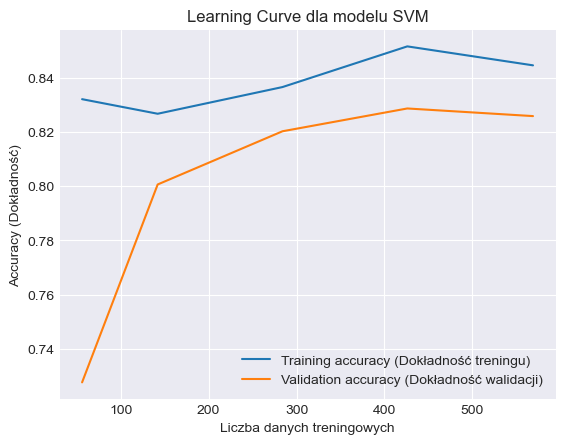

In [39]:
# plt.style.available
plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(train_sizes, train_scores_mean, label='Training accuracy (Dokładność treningu)')
plt.plot(train_sizes, validation_scores_mean, label='Validation accuracy (Dokładność walidacji)')
plt.title('Learning Curve dla modelu SVM')
plt.xlabel('Liczba danych treningowych')
plt.ylabel('Accuracy (Dokładność)')
plt.legend()
plt.show()

In [40]:
for train_size, amount_of_data, train, validation in zip([0.1, 0.25, 0.5, 0.75, 1], train_sizes, train_scores_mean, validation_scores_mean):
    print(f'Wyniki dla zbioru treningowego wynoszącego {(train_size*100):.2f}% ({amount_of_data}) wszystkich danych.')
    print(f'Accuracy dla treningu: {(train*100):.2f}%, dla walidacji: {(validation*100):.2f}%.')
    print(f'Różnica procentowa pomiędzy krzywą treningową, a walidacyjną wynosi: {((train - validation)*100):.2f}%.\n')

Wyniki dla zbioru treningowego wynoszącego 10.00% (56) wszystkich danych.
Accuracy dla treningu: 83.21%, dla walidacji: 72.75%.
Różnica procentowa pomiędzy krzywą treningową, a walidacyjną wynosi: 10.46%.

Wyniki dla zbioru treningowego wynoszącego 25.00% (142) wszystkich danych.
Accuracy dla treningu: 82.68%, dla walidacji: 80.06%.
Różnica procentowa pomiędzy krzywą treningową, a walidacyjną wynosi: 2.61%.

Wyniki dla zbioru treningowego wynoszącego 50.00% (284) wszystkich danych.
Accuracy dla treningu: 83.66%, dla walidacji: 82.03%.
Różnica procentowa pomiędzy krzywą treningową, a walidacyjną wynosi: 1.63%.

Wyniki dla zbioru treningowego wynoszącego 75.00% (426) wszystkich danych.
Accuracy dla treningu: 85.16%, dla walidacji: 82.87%.
Różnica procentowa pomiędzy krzywą treningową, a walidacyjną wynosi: 2.29%.

Wyniki dla zbioru treningowego wynoszącego 100.00% (569) wszystkich danych.
Accuracy dla treningu: 84.46%, dla walidacji: 82.59%.
Różnica procentowa pomiędzy krzywą treningową,